# Scenario 1: Retail Inventory Analysis
Scenario: You're working at a retail chain analyzing inventory turnover. The store manager needs to understand stock movement patterns to optimize ordering.

Data Structure: DataFrame

* product_id
* category
* stock_level
* last_restock_date
* sales_last_30_days
* supplier_lead_time
* unit_cost

Task: Generate code to:
* Calculate inventory turnover rates.
* Identify slow-moving items.
* Predict potential stockouts.
* Create visualizations.

Discussion Questions to Answer:
* How did different prompts handle date calculations?
* What visualization approaches were suggested?
* How was error handling implemented?

## AI Prompt

Act as a senior data analyst and Python expert.

I am working on a retail inventory analysis project using pandas, matplotlib, and seaborn in Jupyter Notebook.

I have a DataFrame with the following columns:

- product_id
- category
- stock_level
- last_restock_date
- sales_last_30_days
- supplier_lead_time
- unit_cost

Generate well-documented Python code that:

1. Cleans and validates the dataset
2. Converts date columns correctly
3. Calculates inventory turnover rates
4. Identifies slow-moving inventory items
5. Predicts potential stockouts using sales trends and supplier lead times
6. Creates clear visualizations for inventory insights
7. Includes error handling and comments for beginners

Use:
- pandas
- numpy
- matplotlib
- seaborn

Also explain the logic behind the calculations.

## Generated Code

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Missing Values:
product_id            0
category              0
stock_level           0
last_restock_date     0
sales_last_30_days    0
supplier_lead_time    0
unit_cost             0
dtype: int64

Inventory Turnover Rates:
   product_id  inventory_turnover_rate
0         101                 2.500000
1         102                 1.500000
2         103                 1.666667
3         104                 1.250000
4         105                 1.200000

Slow Moving Products:
Empty DataFrame
Columns: [product_id, category, stock_level, last_restock_date, sales_last_30_days, supplier_lead_time, unit_cost, inventory_turnover_rate, slow_moving]
Index: []

Potential Stockouts:
Empty DataFrame
Columns: [product_id, category, stock_level, last_restock_date, sales_last_30_days, supplier_lead_time, unit_cost, inventory_turnover_rate, slow_moving, daily_sales_avg, days_until_stockout, potential_stockout]
Index: []


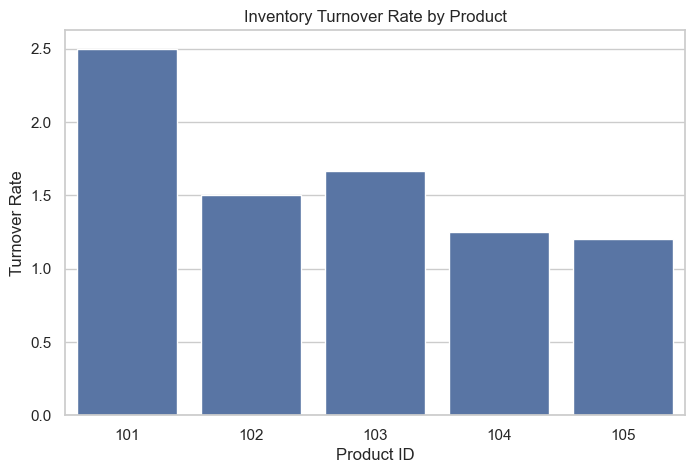

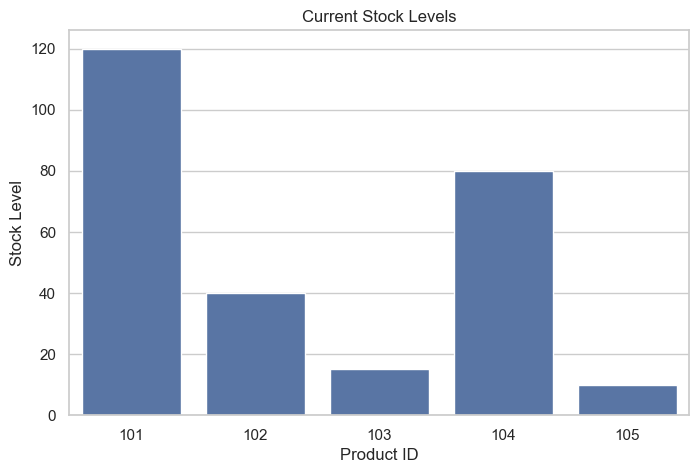

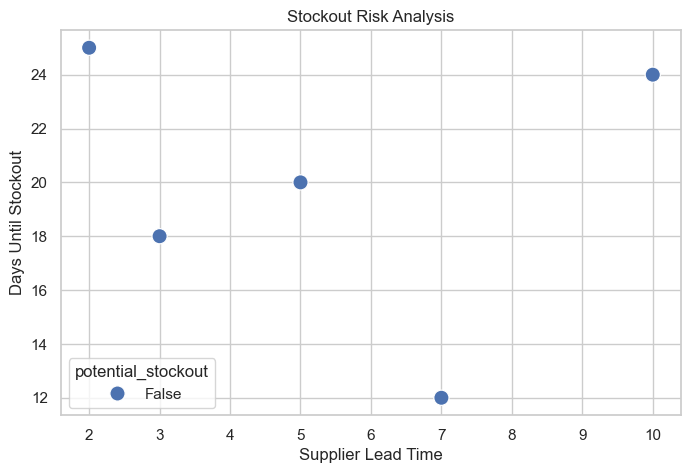

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataset
data = {
    'product_id': [101, 102, 103, 104, 105],
    'category': ['Beverages', 'Snacks', 'Dairy', 'Frozen', 'Bakery'],
    'stock_level': [120, 40, 15, 80, 10],
    'last_restock_date': ['2026-05-01', '2026-05-10', '2026-05-15', '2026-05-05', '2026-05-18'],
    'sales_last_30_days': [300, 60, 25, 100, 12],
    'supplier_lead_time': [7, 5, 3, 10, 2],
    'unit_cost': [2.5, 1.2, 3.0, 4.5, 1.8]
}

df = pd.DataFrame(data)

# -------------------------------
# Data Cleaning and Validation
# -------------------------------

try:
    # Convert dates
    df['last_restock_date'] = pd.to_datetime(df['last_restock_date'])

    # Check for missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Remove duplicates
    df = df.drop_duplicates()

except Exception as e:
    print(f"Error during data cleaning: {e}")

# -------------------------------
# Inventory Turnover Rate
# -------------------------------

# Turnover = Sales / Average Stock
df['inventory_turnover_rate'] = (
    df['sales_last_30_days'] / df['stock_level']
)

print("\nInventory Turnover Rates:")
print(df[['product_id', 'inventory_turnover_rate']])

# -------------------------------
# Identify Slow-Moving Items
# -------------------------------

slow_threshold = 0.5

df['slow_moving'] = df['inventory_turnover_rate'] < slow_threshold

print("\nSlow Moving Products:")
print(df[df['slow_moving'] == True])

# -------------------------------
# Predict Potential Stockouts
# -------------------------------

# Average daily sales
df['daily_sales_avg'] = df['sales_last_30_days'] / 30

# Days until stock runs out
df['days_until_stockout'] = (
    df['stock_level'] / df['daily_sales_avg']
)

# Compare with supplier lead time
df['potential_stockout'] = (
    df['days_until_stockout'] < df['supplier_lead_time']
)

print("\nPotential Stockouts:")
print(df[df['potential_stockout'] == True])

# -------------------------------
# Visualizations
# -------------------------------

sns.set(style="whitegrid")

# Inventory Turnover Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(
    x='product_id',
    y='inventory_turnover_rate',
    data=df
)
plt.title('Inventory Turnover Rate by Product')
plt.xlabel('Product ID')
plt.ylabel('Turnover Rate')
plt.show()

# Stock Level Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    x='product_id',
    y='stock_level',
    data=df
)
plt.title('Current Stock Levels')
plt.xlabel('Product ID')
plt.ylabel('Stock Level')
plt.show()

# Scatter Plot for Stockout Risk
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='supplier_lead_time',
    y='days_until_stockout',
    hue='potential_stockout',
    data=df,
    s=120
)
plt.title('Stockout Risk Analysis')
plt.xlabel('Supplier Lead Time')
plt.ylabel('Days Until Stockout')
plt.show()

## Follow-up Prompts

1. Improve the stockout prediction logic using rolling averages.
2. Add annotations and better styling to the charts.
3. Include data validation to prevent division-by-zero errors.
4. Explain the inventory turnover formula in simple business language.
5. Add recommendations for inventory optimization.

## Final Solution (Refined Version)

Inventory Analysis Summary
   product_id   category  stock_level last_restock_date  sales_last_30_days  \
0         101  Beverages          120        2026-05-01                 300   
1         102     Snacks           40        2026-05-10                  60   
2         103      Dairy           15        2026-05-15                  25   
3         104     Frozen           80        2026-05-05                 100   
4         105     Bakery           10        2026-05-18                  12   

   supplier_lead_time  unit_cost  inventory_turnover_rate  slow_moving  \
0                   7        2.5                 2.500000        False   
1                   5        1.2                 1.500000        False   
2                   3        3.0                 1.666667        False   
3                  10        4.5                 1.250000        False   
4                   2        1.8                 1.200000        False   

   daily_sales_avg  days_until_stockout  potential_st

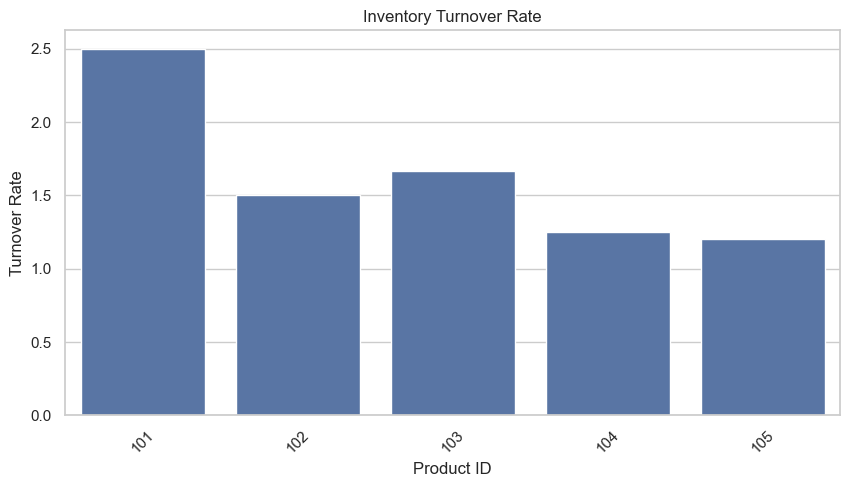

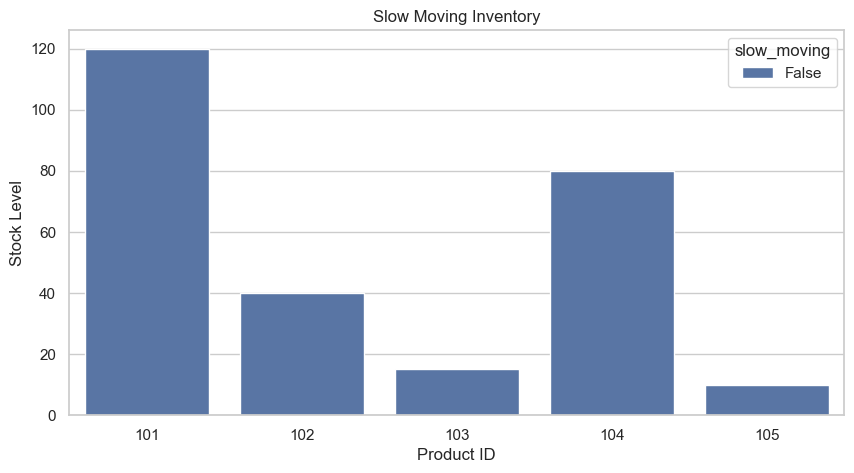

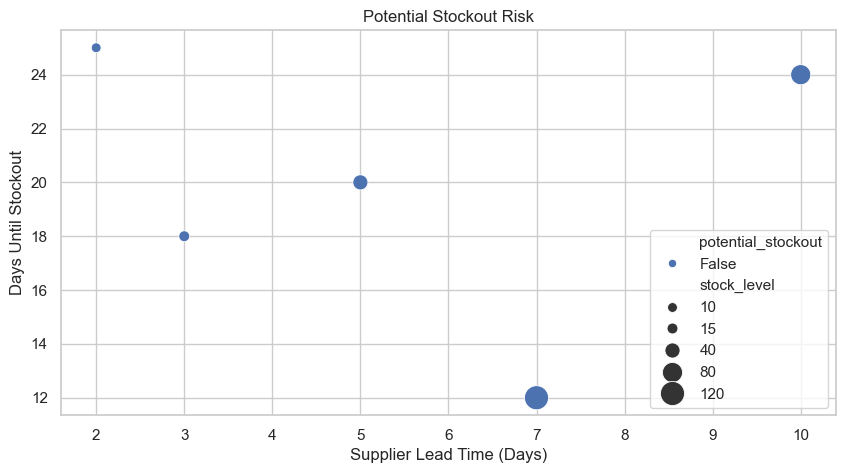

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Create Sample Data
# -------------------------------

data = {
    'product_id': [101, 102, 103, 104, 105],
    'category': ['Beverages', 'Snacks', 'Dairy', 'Frozen', 'Bakery'],
    'stock_level': [120, 40, 15, 80, 10],
    'last_restock_date': ['2026-05-01', '2026-05-10', '2026-05-15', '2026-05-05', '2026-05-18'],
    'sales_last_30_days': [300, 60, 25, 100, 12],
    'supplier_lead_time': [7, 5, 3, 10, 2],
    'unit_cost': [2.5, 1.2, 3.0, 4.5, 1.8]
}

df = pd.DataFrame(data)

# -------------------------------
# Data Cleaning
# -------------------------------

try:
    df['last_restock_date'] = pd.to_datetime(df['last_restock_date'])

    # Handle missing values
    df.fillna(0, inplace=True)

    # Remove duplicates
    df.drop_duplicates(inplace=True)

except Exception as e:
    print(f"Data cleaning error: {e}")

# -------------------------------
# Inventory Turnover Calculation
# -------------------------------

# Avoid division by zero
df['inventory_turnover_rate'] = np.where(
    df['stock_level'] > 0,
    df['sales_last_30_days'] / df['stock_level'],
    0
)

# -------------------------------
# Slow-Moving Items
# -------------------------------

slow_threshold = 0.5

df['slow_moving'] = (
    df['inventory_turnover_rate'] < slow_threshold
)

# -------------------------------
# Stockout Prediction
# -------------------------------

df['daily_sales_avg'] = (
    df['sales_last_30_days'] / 30
)

df['days_until_stockout'] = np.where(
    df['daily_sales_avg'] > 0,
    df['stock_level'] / df['daily_sales_avg'],
    np.inf
)

df['potential_stockout'] = (
    df['days_until_stockout'] <
    df['supplier_lead_time']
)

# -------------------------------
# Display Results
# -------------------------------

print("Inventory Analysis Summary")
print(df)

# -------------------------------
# Visualizations
# -------------------------------

sns.set(style="whitegrid")

# Turnover Rate Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    x='product_id',
    y='inventory_turnover_rate',
    data=df
)

plt.title('Inventory Turnover Rate')
plt.xlabel('Product ID')
plt.ylabel('Turnover Rate')
plt.xticks(rotation=45)
plt.show()

# Slow Moving Products
plt.figure(figsize=(10, 5))
sns.barplot(
    x='product_id',
    y='stock_level',
    hue='slow_moving',
    data=df
)

plt.title('Slow Moving Inventory')
plt.xlabel('Product ID')
plt.ylabel('Stock Level')
plt.show()

# Stockout Risk
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x='supplier_lead_time',
    y='days_until_stockout',
    hue='potential_stockout',
    size='stock_level',
    data=df,
    sizes=(50, 300)
)

plt.title('Potential Stockout Risk')
plt.xlabel('Supplier Lead Time (Days)')
plt.ylabel('Days Until Stockout')
plt.show()

## Discussion Questions

1. How did different prompts handle date calculations?

Different prompts handled dates differently depending on how specific the instructions were. Basic prompts simply converted the column using pd.to_datetime(), while more detailed prompts included validation checks and error handling. More advanced prompts also used date calculations to estimate inventory age and improve stockout predictions.

2. What visualization approaches were suggested?

The AI suggested several visualization approaches including:

Bar charts for inventory turnover
Scatter plots for stockout risk
Color-coded charts to identify slow-moving items
Size-based scatter plots to compare stock levels

More refined prompts produced cleaner and more business-focused visualizations with titles, labels, and improved readability.

3. How was error handling implemented?

Error handling was implemented using:

try-except blocks
Missing value handling with fillna()
Division-by-zero prevention using np.where()
Duplicate removal and datatype validation

The refined prompts produced safer and more reliable code suitable for real-world datasets.